# 진동 데이터 이상 탐지 - AutoML (PyCaret)
> **데이터**: vibration_normal.csv (1,774개) / vibration_anomaly.csv (16개)  
> **목적**: 로봇 용접기 진동 데이터에서 이상(결함) 상태 자동 탐지  
> **방법**: 데이터 특성 분석 → 모델 자동 추천 → AutoML 비교 → 최적 모델 선정

## 0. 패키지 설치

In [ ]:
# PyCaret 설치 (최초 1회만 실행)
# 지원 Python 버전: 3.8 이상 / 권장: 3.9 ~ 3.11
!pip install pycaret[anomaly]

## 1. 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings("ignore")

from pycaret.anomaly import (
    setup, create_model, assign_model,
    plot_model, save_model, load_model
)

import platform

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


## 2. 시각화 공통 설정

In [5]:
# ── OS 자동 감지 ──────────────────────────────────────
system = platform.system()
plt.rcParams['font.family'] = 'Malgun Gothic'       # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False    

plt.rc("font",   size=14)
plt.rc("axes",   labelsize=14)
plt.rc("xtick",  labelsize=12)
plt.rc("ytick",  labelsize=12)
plt.rc("legend", fontsize=12)
plt.rc("figure", titlesize=18)
print("✅ 시각화 설정 완료")

✅ 시각화 설정 완료


## 3. 데이터 로드

In [6]:
vib_normal_ds  = pd.read_csv("data/vibration_normal.csv",  index_col="Time")
vib_anomaly_ds = pd.read_csv("data/vibration_anomaly.csv", index_col="Time")

print("정상 진동 데이터 shape :", vib_normal_ds.shape)
print("이상 진동 데이터 shape :", vib_anomaly_ds.shape)
vib_normal_ds.head()

정상 진동 데이터 shape : (1774, 512)
이상 진동 데이터 shape : (16, 512)


,0,3.12,6.25,9.38,12.5,15.62,18.75,21.88,25,28.12,...,1568.75,1571.88,1575,1578.12,1581.25,1584.38,1587.5,1590.62,1593.75,1596.88
Time,,,,,,,,,,,,,,,,,,,,,
2021-08-02 6:47,0.000448,0.000634,0.000895,0.001124,0.000333,0.000583,0.000242,0.000743,0.001193,0.001020,...,0.000317,0.000457,0.000994,0.000815,0.000344,0.000280,0.000636,0.000639,0.000780,0.000728
2021-08-02 7:12,0.000001,0.000176,0.000315,0.000793,0.001073,0.001130,0.001330,0.000867,0.000609,0.000444,...,0.000352,0.000346,0.000111,0.000173,0.000533,0.000419,0.000422,0.000654,0.000172,0.000238
2021-08-02 7:36,0.000594,0.000379,0.001343,0.000454,0.000517,0.000454,0.000693,0.001282,0.001232,0.001127,...,0.000143,0.000389,0.000983,0.000983,0.000157,0.000881,0.001318,0.000757,0.000638,0.000872
2021-08-02 7:59,0.000168,0.000438,0.000732,0.000812,0.000957,0.000835,0.001051,0.000489,0.000181,0.000340,...,0.000894,0.000802,0.000983,0.000872,0.000740,0.000222,0.000566,0.000917,0.000849,0.000489
2021-08-02 8:27,0.000370,0.000512,0.000656,0.000267,0.000236,0.000236,0.000305,0.000629,0.001426,0.001326,...,0.000731,0.000453,0.000630,0.000712,0.000496,0.000706,0.000513,0.000119,0.000599,0.000746


## 4. 📊 데이터 특성 자동 분석
> 아래 8가지 특성을 측정하여 어떤 모델이 적합한지 자동으로 판단합니다.

| 분석 항목 | 의미 |
|---|---|
| 샘플 수 | 데이터 크기 → 느린 모델 제외 여부 |
| 피처 수 | 차원 → 고차원이면 PCA 계열 유리 |
| 이상치 비율 | 클래스 불균형 정도 |
| 정규분포 여부 | 분포 형태 → 통계 기반 모델 적합성 |
| 피처 간 상관관계 | 상관성 높으면 PCA 유리 |
| 피처별 분산 | 분산이 다양하면 정규화 필요 |
| 이상치 강도 | 정상 vs 이상의 차이 크기 |
| 결측치 여부 | 전처리 필요 여부 |

In [7]:
def analyze_data_profile(normal_df, anomaly_df):
    """
    데이터 특성을 8가지 항목으로 분석하여 프로파일 딕셔너리를 반환합니다.
    """
    X_normal  = normal_df.values
    X_anomaly = anomaly_df.values
    n_samples  = len(X_normal)
    n_features = X_normal.shape[1]
    anomaly_ratio = len(X_anomaly) / (len(X_normal) + len(X_anomaly))

    # ── (1) 정규분포 여부: 피처 샘플링 후 Shapiro-Wilk 검정
    n_test   = min(30, n_features)
    p_values = []
    for i in range(n_test):
        col = X_normal[:, i]
        sample = col[~np.isnan(col)][:5000]   # Shapiro는 최대 5000
        if len(sample) >= 3:
            _, p = stats.shapiro(sample[:min(len(sample), 300)])
            p_values.append(p)
    normal_ratio = np.mean([p > 0.05 for p in p_values]) if p_values else 0.0

    # ── (2) 피처 간 상관관계 (샘플링)
    n_corr_feat  = min(50, n_features)
    corr_matrix  = np.corrcoef(X_normal[:, :n_corr_feat].T)
    upper_tri    = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
    mean_corr    = float(np.nanmean(np.abs(upper_tri)))

    # ── (3) 피처별 분산 (표준화 전)
    feat_stds    = X_normal.std(axis=0)
    std_cv       = feat_stds.std() / (feat_stds.mean() + 1e-9)  # 변동계수

    # ── (4) 이상치 강도: 정상 평균 vs 이상 평균의 분리도
    mean_diff    = np.abs(X_normal.mean(axis=0) - X_anomaly.mean(axis=0))
    pooled_std   = (X_normal.std(axis=0) + X_anomaly.std(axis=0)) / 2 + 1e-9
    separation   = float(np.mean(mean_diff / pooled_std))   # Cohen's d 유사값

    # ── (5) 결측치 비율
    missing_ratio = float(pd.DataFrame(X_normal).isnull().mean().mean())

    profile = {
        "n_samples"      : n_samples,
        "n_features"     : n_features,
        "anomaly_ratio"  : anomaly_ratio,
        "normal_ratio"   : normal_ratio,   # 정규분포 비율 (0~1)
        "mean_corr"      : mean_corr,      # 평균 상관계수 (0~1)
        "std_cv"         : std_cv,         # 분산의 변동계수
        "separation"     : separation,     # 정상/이상 분리도
        "missing_ratio"  : missing_ratio,  # 결측치 비율
    }
    return profile


profile = analyze_data_profile(vib_normal_ds, vib_anomaly_ds)

print("=" * 55)
print("       📊 데이터 특성 분석 결과")
print("=" * 55)
print(f"  샘플 수           : {profile['n_samples']:,}개")
print(f"  피처 수           : {profile['n_features']:,}개")
print(f"  이상치 비율       : {profile['anomaly_ratio']:.2%}")
print(f"  정규분포 비율     : {profile['normal_ratio']:.2%}  "
      f"({'정규분포에 가까움' if profile['normal_ratio']>0.5 else '비정규분포'})")
print(f"  평균 피처 상관관계: {profile['mean_corr']:.4f}  "
      f"({'상관성 높음' if profile['mean_corr']>0.3 else '상관성 낮음'})")
print(f"  분산 변동계수     : {profile['std_cv']:.4f}  "
      f"({'분산 다양' if profile['std_cv']>0.5 else '분산 균일'})")
print(f"  정상/이상 분리도  : {profile['separation']:.4f}  "
      f"({'잘 분리됨' if profile['separation']>1.0 else '분리 어려움'})")
print(f"  결측치 비율       : {profile['missing_ratio']:.2%}")
print("=" * 55)

       📊 데이터 특성 분석 결과
  샘플 수           : 1,774개
  피처 수           : 512개
  이상치 비율       : 0.89%
  정규분포 비율     : 0.00%  (비정규분포)
  평균 피처 상관관계: 0.4408  (상관성 높음)
  분산 변동계수     : 0.5347  (분산 다양)
  정상/이상 분리도  : 2.5122  (잘 분리됨)
  결측치 비율       : 0.00%


## 5. 🤖 데이터 기반 모델 자동 추천
> 분석된 데이터 특성에 따라 각 모델의 **적합도 점수**를 계산하고,  
> 점수가 높은 상위 모델만 선별하여 AutoML을 실행합니다.

In [8]:
# ── 전체 후보 모델 메타데이터 정의 ─────────────────────────────
ALL_MODELS = {
    "iforest": {
        "name"       : "Isolation Forest",
        "desc"       : "트리 기반 이상 분리. 고차원·대용량에 강함",
        "strengths"  : ["고차원", "대용량", "빠른 속도", "이상치 비율 낮음"],
    },
    "lof": {
        "name"       : "Local Outlier Factor",
        "desc"       : "밀도 기반 지역 이상 탐지. 클러스터 구조 데이터에 강함",
        "strengths"  : ["밀도 차이", "클러스터", "소규모"],
    },
    "knn": {
        "name"       : "K-Nearest Neighbors",
        "desc"       : "거리 기반 이상 탐지. 직관적이며 작은 데이터셋에 적합",
        "strengths"  : ["소규모", "저차원", "분리도 높음"],
    },
    "pca": {
        "name"       : "PCA-Based Anomaly Detection",
        "desc"       : "차원 축소 후 복원 오차 기반. 상관성 높은 데이터에 강함",
        "strengths"  : ["고차원", "상관성 높음", "정규분포"],
    },
    "svm": {
        "name"       : "One-Class SVM",
        "desc"       : "정상 데이터 경계 학습. 저차원·소규모에 적합",
        "strengths"  : ["소규모", "저차원", "정규분포"],
    },
    "histogram": {
        "name"       : "Histogram-Based Outlier Detection",
        "desc"       : "히스토그램 밀도 추정. 빠르고 단변량 이상에 강함",
        "strengths"  : ["대용량", "빠른 속도", "단변량"],
    },
    "cluster": {
        "name"       : "Clustering-Based Outlier",
        "desc"       : "클러스터 중심과의 거리 기반. 군집 구조가 명확할 때 유리",
        "strengths"  : ["클러스터", "분리도 높음"],
    },
    "mcd": {
        "name"       : "Minimum Covariance Determinant",
        "desc"       : "공분산 기반 이상 탐지. 정규분포 가정 데이터에 강함",
        "strengths"  : ["정규분포", "상관성 높음", "소규모"],
    },
}


def score_models(profile, all_models):
    """
    데이터 프로파일을 기반으로 각 모델의 적합도 점수를 계산합니다.

    채점 기준 (각 항목 0~1 점수, 가중합):
      - 데이터 크기 적합성     : 15%
      - 차원 적합성            : 20%
      - 이상치 비율 적합성     : 15%
      - 분포 적합성            : 15%
      - 상관관계 적합성        : 15%
      - 분리도 적합성          : 20%
    """
    n   = profile["n_samples"]
    d   = profile["n_features"]
    ar  = profile["anomaly_ratio"]
    nr  = profile["normal_ratio"]
    mc  = profile["mean_corr"]
    sep = profile["separation"]

    scores = {}

    for mid, meta in all_models.items():
        s = {}

        # ── (A) 데이터 크기 적합성 (15%) ─────────────────────────
        if mid in ("iforest", "histogram"):
            # 대용량에 강함: 샘플 많을수록 유리
            s["size"] = min(1.0, n / 5000)
        elif mid in ("knn", "lof", "svm", "mcd"):
            # 소규모에 적합: 샘플 너무 많으면 느림
            s["size"] = max(0.0, 1.0 - n / 10000)
        else:
            s["size"] = 0.5

        # ── (B) 차원 적합성 (20%) ─────────────────────────────────
        if mid in ("pca", "iforest"):
            # 고차원에 강함
            s["dim"] = min(1.0, d / 200)
        elif mid in ("knn", "svm"):
            # 저차원에 적합
            s["dim"] = max(0.0, 1.0 - d / 500)
        elif mid in ("lof", "cluster"):
            s["dim"] = max(0.2, 1.0 - d / 1000)
        else:
            s["dim"] = 0.5

        # ── (C) 이상치 비율 적합성 (15%) ─────────────────────────
        if mid == "iforest":
            # 이상치 비율 낮을수록 (1% 내외) Isolation Forest 유리
            s["ratio"] = max(0.0, 1.0 - abs(ar - 0.01) * 20)
        elif mid in ("lof", "knn"):
            s["ratio"] = max(0.0, 1.0 - abs(ar - 0.05) * 10)
        else:
            s["ratio"] = 0.5

        # ── (D) 분포 적합성 (15%) ─────────────────────────────────
        if mid in ("pca", "svm", "mcd"):
            # 정규분포 가정 모델: 정규분포일수록 유리
            s["dist"] = nr
        elif mid in ("iforest", "histogram", "lof"):
            # 분포 무관 모델: 비정규분포일 때 상대적으로 유리
            s["dist"] = 1.0 - nr * 0.3
        else:
            s["dist"] = 0.5

        # ── (E) 상관관계 적합성 (15%) ─────────────────────────────
        if mid == "pca":
            # 상관관계 높을수록 PCA 차원 축소 효과 큼
            s["corr"] = mc
        elif mid in ("iforest", "histogram"):
            # 상관관계 무관
            s["corr"] = 0.6
        else:
            s["corr"] = 1.0 - mc * 0.5

        # ── (F) 정상/이상 분리도 적합성 (20%) ────────────────────
        if mid in ("knn", "lof", "cluster"):
            # 분리도 높을수록 거리/밀도 기반 모델 유리
            s["sep"] = min(1.0, sep / 2.0)
        elif mid in ("iforest", "histogram"):
            # 분리도 낮아도 잘 동작
            s["sep"] = 0.6 + min(0.4, sep / 5.0)
        else:
            s["sep"] = min(1.0, sep / 3.0)

        # ── 가중합 계산 ───────────────────────────────────────────
        weights = {
            "size" : 0.15,
            "dim"  : 0.20,
            "ratio": 0.15,
            "dist" : 0.15,
            "corr" : 0.15,
            "sep"  : 0.20,
        }
        total = sum(s[k] * weights[k] for k in weights)
        scores[mid] = {
            "total"       : total,
            "sub_scores"  : s,
            "name"        : meta["name"],
            "desc"        : meta["desc"],
        }

    return scores


model_scores = score_models(profile, ALL_MODELS)
score_df = pd.DataFrame([
    {"모델 ID": mid, "모델명": v["name"],
     "적합도 점수": v["total"], "설명": v["desc"]}
    for mid, v in model_scores.items()
]).sort_values("적합도 점수", ascending=False).reset_index(drop=True)

print("=" * 75)
print("    🤖 데이터 기반 모델 적합도 점수 (높을수록 적합)")
print("=" * 75)
for i, row in score_df.iterrows():
    bar   = "█" * int(row["적합도 점수"] * 20)
    medal = {0:"🥇", 1:"🥈", 2:"🥉"}.get(i, "  ")
    print(f"  {medal} {row['모델 ID']:<10} {bar:<20} "
          f"{row['적합도 점수']:.4f}  {row['설명']}")
print("=" * 75)

    🤖 데이터 기반 모델 적합도 점수 (높을수록 적합)
  🥇 iforest    ████████████████     0.8400  트리 기반 이상 분리. 고차원·대용량에 강함
  🥈 lof        ███████████████      0.7763  밀도 기반 지역 이상 탐지. 클러스터 구조 데이터에 강함
  🥉 histogram  █████████████        0.6682  히스토그램 밀도 추정. 빠르고 단변량 이상에 강함
     cluster    ████████████         0.6395  클러스터 중심과의 거리 기반. 군집 구조가 명확할 때 유리
     knn        ████████████         0.6037  거리 기반 이상 탐지. 직관적이며 작은 데이터셋에 적합
     pca        ███████████          0.5836  차원 축소 후 복원 오차 기반. 상관성 높은 데이터에 강함
     mcd        ███████████          0.5828  공분산 기반 이상 탐지. 정규분포 가정 데이터에 강함
     svm        █████████            0.4828  정상 데이터 경계 학습. 저차원·소규모에 적합


### 5-1. 추천 모델 자동 선정

In [9]:
def select_recommended_models(model_scores, top_n=4, min_score=0.45):
    """
    적합도 점수 기준 상위 N개 모델을 선택합니다.
    단, min_score 미만인 모델은 제외합니다.
    """
    sorted_models = sorted(
        model_scores.items(),
        key=lambda x: x[1]["total"],
        reverse=True
    )
    selected = [
        mid for mid, v in sorted_models
        if v["total"] >= min_score
    ][:top_n]

    return selected


MODELS = select_recommended_models(model_scores, top_n=4, min_score=0.45)

print("┌─────────────────────────────────────────────────────────┐")
print("│          ✅ 자동 추천 모델 목록                          │")
print("├──────┬──────────────┬──────────────────────────────────┤")
print("│ 순위 │  모델 ID     │  모델명                           │")
print("├──────┼──────────────┼──────────────────────────────────┤")
for i, mid in enumerate(MODELS, 1):
    name  = model_scores[mid]["name"]
    score = model_scores[mid]["total"]
    medal = {1:"🥇", 2:"🥈", 3:"🥉"}.get(i, f" {i}위")
    print(f"│  {medal}  │  {mid:<12}│  {name:<34}│  ({score:.4f})")
print("└──────┴──────────────┴──────────────────────────────────┘")
print(f"\n→ MODELS = {MODELS}")

┌─────────────────────────────────────────────────────────┐
│          ✅ 자동 추천 모델 목록                          │
├──────┬──────────────┬──────────────────────────────────┤
│ 순위 │  모델 ID     │  모델명                           │
├──────┼──────────────┼──────────────────────────────────┤
│  🥇  │  iforest     │  Isolation Forest                  │  (0.8400)
│  🥈  │  lof         │  Local Outlier Factor              │  (0.7763)
│  🥉  │  histogram   │  Histogram-Based Outlier Detection │  (0.6682)
│   4위  │  cluster     │  Clustering-Based Outlier          │  (0.6395)
└──────┴──────────────┴──────────────────────────────────┘

→ MODELS = ['iforest', 'lof', 'histogram', 'cluster']


### 5-2. 모델 적합도 점수 시각화

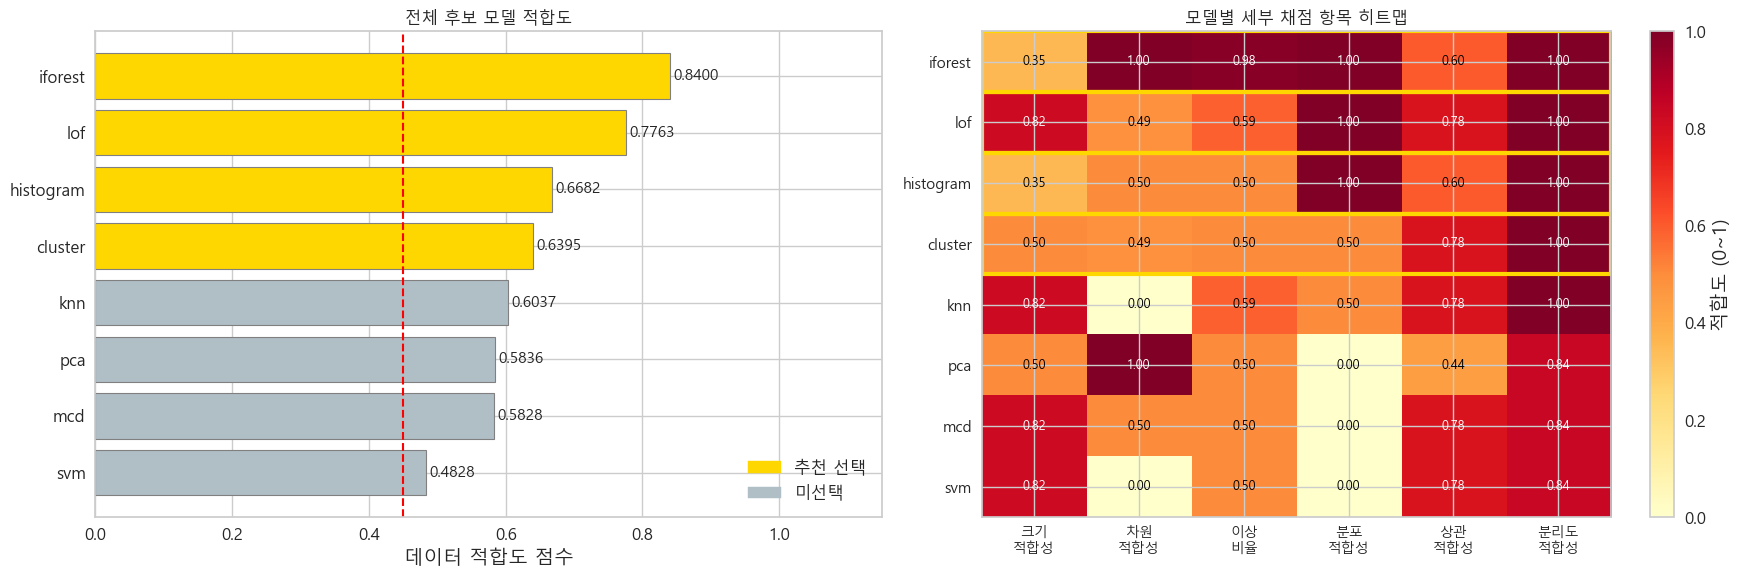

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 왼쪽: 전체 모델 적합도 가로 막대 ────────────────────────────
all_ids    = score_df["모델 ID"].tolist()
all_scores = score_df["적합도 점수"].tolist()
bar_colors = ["#FFD700" if mid in MODELS else "#B0BEC5" for mid in all_ids]

bars = axes[0].barh(all_ids, all_scores,
                    color=bar_colors, edgecolor="gray", linewidth=0.8)
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{w:.4f}", va="center", fontsize=11)
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel("데이터 적합도 점수")
axes[0].set_title("전체 후보 모델 적합도")
axes[0].invert_yaxis()
axes[0].axvline(x=0.45, color="red", linestyle="--",
                linewidth=1.5, label="최소 임계점 (0.45)")
gold_p = mpatches.Patch(color="#FFD700", label="추천 선택")
gray_p = mpatches.Patch(color="#B0BEC5", label="미선택")
axes[0].legend(handles=[gold_p, gray_p, ], loc="lower right")

# ── 오른쪽: 세부 채점 항목 히트맵 ────────────────────────────────
sub_keys   = ["size", "dim", "ratio", "dist", "corr", "sep"]
sub_labels = ["크기\n적합성", "차원\n적합성", "이상\n비율",
              "분포\n적합성", "상관\n적합성", "분리도\n적합성"]
sub_matrix = np.array([
    [model_scores[mid]["sub_scores"][k] for k in sub_keys]
    for mid in all_ids
])

im = axes[1].imshow(sub_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(sub_keys)))
axes[1].set_xticklabels(sub_labels, fontsize=10)
axes[1].set_yticks(range(len(all_ids)))
axes[1].set_yticklabels(all_ids, fontsize=11)

for i in range(len(all_ids)):
    for j in range(len(sub_keys)):
        val = sub_matrix[i, j]
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9,
                     color="white" if val > 0.65 else "black")

plt.colorbar(im, ax=axes[1], label="적합도 (0~1)")
axes[1].set_title("모델별 세부 채점 항목 히트맵")

# 추천 모델 행 강조
for i, mid in enumerate(all_ids):
    if mid in MODELS:
        axes[1].add_patch(plt.Rectangle(
            (-0.5, i-0.5), len(sub_keys), 1,
            fill=False, edgecolor="#FFD700", linewidth=3))

plt.tight_layout()
plt.show()

## 6. AutoML 학습 데이터 준비

In [11]:
vib_normal_ds["label"]  = 0
vib_anomaly_ds["label"] = 1

all_data = pd.concat([vib_normal_ds, vib_anomaly_ds], ignore_index=True)
X        = all_data.drop(columns=["label"])
y_true   = all_data["label"]

print(f"전체 데이터 shape : {X.shape}")
print(f"정상 샘플 수      : {(y_true==0).sum()}")
print(f"이상 샘플 수      : {(y_true==1).sum()}")

전체 데이터 shape : (1790, 512)
정상 샘플 수      : 1774
이상 샘플 수      : 16


## 7. PyCaret AutoML 환경 세팅

In [12]:
anomaly_setup = setup(
    data       = X,
    session_id = 42,
    normalize  = True,
    verbose    = True
)
print("\n✅ PyCaret 세팅 완료")

,Description,Value
0,Session id,42
1,Original data shape,"(1790, 512)"
2,Transformed data shape,"(1790, 512)"
3,Numeric features,512
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore



✅ PyCaret 세팅 완료


## 8. 추천 모델 자동 학습

In [13]:
FRACTION = 0.01
results  = {}

print(f"추천 모델 {len(MODELS)}개 학습 시작: {MODELS}\n")
for model_id in MODELS:
    score = model_scores[model_id]["total"]
    name  = model_scores[model_id]["name"]
    print(f"  ▶ [{model_id}] {name}  (적합도={score:.4f}) 학습 중 ...", end=" ")
    model     = create_model(model_id, fraction=FRACTION)
    result_df = assign_model(model)
    results[model_id] = {"model": model, "result": result_df}
    print(f"탐지 이상 수: {(result_df['Anomaly']==1).sum()}개")

print("\n✅ 전체 모델 학습 완료")

추천 모델 4개 학습 시작: ['iforest', 'lof', 'histogram', 'cluster']

  ▶ [iforest] Isolation Forest  (적합도=0.8400) 학습 중 ... 

탐지 이상 수: 18개
  ▶ [lof] Local Outlier Factor  (적합도=0.7763) 학습 중 ... 

탐지 이상 수: 18개
  ▶ [histogram] Histogram-Based Outlier Detection  (적합도=0.6682) 학습 중 ... 

탐지 이상 수: 18개
  ▶ [cluster] Clustering-Based Outlier  (적합도=0.6395) 학습 중 ... 

탐지 이상 수: 18개

✅ 전체 모델 학습 완료


## 9. 모델별 성능 지표 계산

In [14]:
perf_rows = []

for model_id, data in results.items():
    result_df = data["result"]
    y_pred    = result_df["Anomaly"].values
    y_score   = result_df["Anomaly_Score"].values

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred,    zero_division=0)
    f1   = f1_score(y_true, y_pred,        zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = 0.0

    perf_rows.append({
        "모델"      : model_id,
        "Precision" : prec,
        "Recall"    : rec,
        "F1-Score"  : f1,
        "AUC"       : auc,
        "적합도"    : model_scores[model_id]["total"],
    })

perf_df = pd.DataFrame(perf_rows).set_index("모델")
display(perf_df.style
        .format({c: "{:.4f}" for c in
                 ["Precision","Recall","F1-Score","AUC","적합도"]})
        .highlight_max(subset=["Precision","Recall","F1-Score","AUC"],
                       color="lightgreen")
        .highlight_min(subset=["Precision","Recall","F1-Score","AUC"],
                       color="#ffcccc"))

,Precision,Recall,F1-Score,AUC,적합도
모델,,,,,
iforest,0.8889,1.0000,0.9412,1.0000,0.8400
lof,0.5556,0.6250,0.5882,0.9968,0.7763
histogram,0.8889,1.0000,0.9412,1.0000,0.6682
cluster,0.8333,0.9375,0.8824,0.9997,0.6395


## 10. ⭐ 최적 모델 자동 추천
> 실제 성능(70%) + 데이터 적합도(30%)를 결합하여 최종 추천 모델을 선정합니다.

In [15]:
PERF_WEIGHTS = {"Recall": 0.40, "F1-Score": 0.30,
                "AUC": 0.20,   "Precision": 0.10}

perf_df["성능 점수"] = sum(
    perf_df[m] * w for m, w in PERF_WEIGHTS.items()
)
# 최종 점수 = 성능 점수 70% + 데이터 적합도 30%
perf_df["최종 점수"] = (
    perf_df["성능 점수"] * 0.70 +
    perf_df["적합도"]    * 0.30
)
perf_df["순위"] = perf_df["최종 점수"].rank(ascending=False).astype(int)
perf_df_sorted = perf_df.sort_values("최종 점수", ascending=False)

print("=" * 70)
print("  📊 최종 추천 순위  (성능 70% + 데이터 적합도 30%)")
print("=" * 70)
for rank, (mid, row) in enumerate(perf_df_sorted.iterrows(), 1):
    medal = {1:"🥇", 2:"🥈", 3:"🥉"}.get(rank, f"  {rank}위")
    print(f"  {medal}  {mid:<12}"
          f"  최종={row['최종 점수']:.4f}"
          f"  성능={row['성능 점수']:.4f}"
          f"  적합도={row['적합도']:.4f}"
          f"  Recall={row['Recall']:.4f}")
print("=" * 70)

best_model_id  = perf_df_sorted.index[0]
best_row       = perf_df_sorted.iloc[0]
print(f"\n✅ 최종 추천 모델 : [{best_model_id}]")
print(f"   최종 점수  : {best_row['최종 점수']:.4f}")
print(f"   Recall     : {best_row['Recall']:.4f}")
print(f"   F1-Score   : {best_row['F1-Score']:.4f}")
print(f"   AUC        : {best_row['AUC']:.4f}")
print(f"   데이터 적합도: {best_row['적합도']:.4f}")

  📊 최종 추천 순위  (성능 70% + 데이터 적합도 30%)
  🥇  iforest       최종=0.9319  성능=0.9712  적합도=0.8400  Recall=1.0000
  🥈  histogram     최종=0.8803  성능=0.9712  적합도=0.6682  Recall=1.0000
  🥉  cluster       최종=0.8379  성능=0.9230  적합도=0.6395  Recall=0.9375
    4위  lof           최종=0.7099  성능=0.6814  적합도=0.7763  Recall=0.6250

✅ 최종 추천 모델 : [iforest]
   최종 점수  : 0.9319
   Recall     : 1.0000
   F1-Score   : 0.9412
   AUC        : 1.0000
   데이터 적합도: 0.8400


### 10-1. 최종 추천 점수 시각화

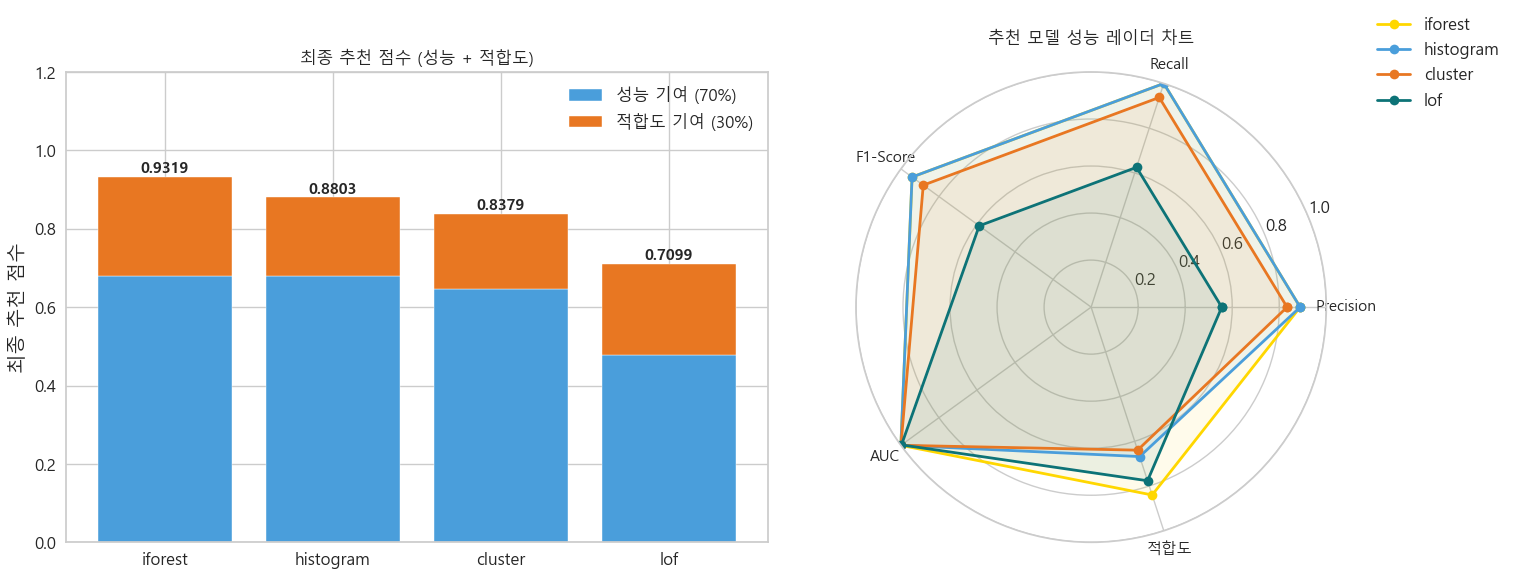

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 왼쪽: 최종 점수 스택 막대 ─────────────────────────────────
model_names = perf_df_sorted.index.tolist()
perf_part   = (perf_df_sorted["성능 점수"] * 0.70).values
fit_part    = (perf_df_sorted["적합도"]    * 0.30).values
x           = np.arange(len(model_names))

b1 = axes[0].bar(x, perf_part, label="성능 기여 (70%)",
                 color="#4A9EDB", edgecolor="white")
b2 = axes[0].bar(x, fit_part,  bottom=perf_part,
                 label="적합도 기여 (30%)", color="#E87722", edgecolor="white")

for i, (p, f) in enumerate(zip(perf_part, fit_part)):
    total = p + f
    axes[0].text(i, total + 0.01, f"{total:.4f}",
                 ha="center", fontsize=11, fontweight="bold")

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=12)
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel("최종 추천 점수")
axes[0].set_title("최종 추천 점수 (성능 + 적합도)")
axes[0].legend()

# ── 오른쪽: 레이더 차트 ────────────────────────────────────────
labels   = ["Precision", "Recall", "F1-Score", "AUC", "적합도"]
n_labels = len(labels)
angles   = np.linspace(0, 2*np.pi, n_labels, endpoint=False).tolist()
angles  += angles[:1]

ax_r = fig.add_subplot(122, polar=True)
axes[1].remove()
radar_colors = ["#FFD700", "#4A9EDB", "#E87722", "#0D7377"]

for i, (mid, row) in enumerate(perf_df_sorted.iterrows()):
    vals  = [row["Precision"], row["Recall"],
             row["F1-Score"],  row["AUC"], row["적합도"]]
    vals += vals[:1]
    ax_r.plot(angles, vals, "o-", linewidth=2,
              color=radar_colors[i % len(radar_colors)], label=mid)
    ax_r.fill(angles, vals, alpha=0.08,
              color=radar_colors[i % len(radar_colors)])

ax_r.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax_r.set_ylim(0, 1)
ax_r.set_title("추천 모델 성능 레이더 차트", pad=20)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15))

plt.tight_layout()
plt.show()

## 11. 최적 모델 상세 분석

In [17]:
best_result = results[best_model_id]["result"]
y_pred_best = best_result["Anomaly"].values
cm          = confusion_matrix(y_true, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"=== [{best_model_id}] 분류 리포트 ===\n")
print(classification_report(y_true, y_pred_best,
                             target_names=["정상(0)", "이상(1)"]))
print(f"  TP (이상→이상 탐지 성공) : {tp}개")
print(f"  TN (정상→정상 판별 성공) : {tn}개")
print(f"  FP (정상→이상 오탐)      : {fp}개")
print(f"  FN (이상→정상 미탐)      : {fn}개")

=== [iforest] 분류 리포트 ===

              precision    recall  f1-score   support

       정상(0)       1.00      1.00      1.00      1774
       이상(1)       0.89      1.00      0.94        16

    accuracy                           1.00      1790
   macro avg       0.94      1.00      0.97      1790
weighted avg       1.00      1.00      1.00      1790

  TP (이상→이상 탐지 성공) : 16개
  TN (정상→정상 판별 성공) : 1772개
  FP (정상→이상 오탐)      : 2개
  FN (이상→정상 미탐)      : 0개


### 11-1. 이상 점수 분포 시각화

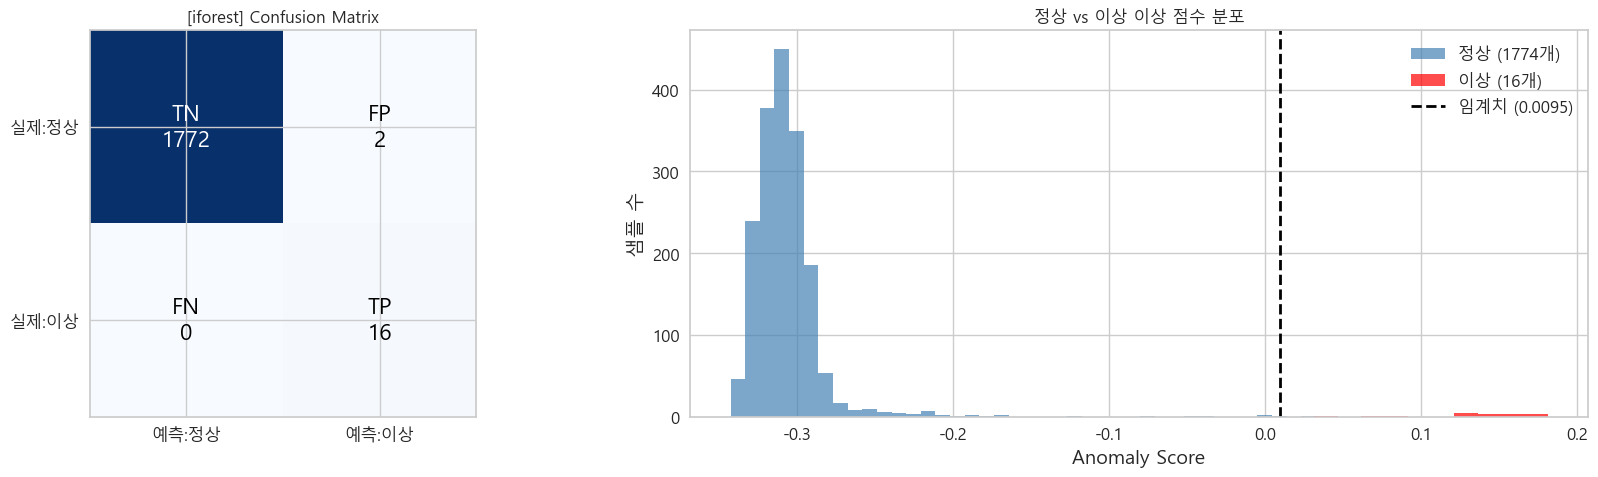

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 혼동 행렬
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(["예측:정상", "예측:이상"])
axes[0].set_yticklabels(["실제:정상", "실제:이상"])
lbl = [["TN","FP"],["FN","TP"]]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{lbl[i][j]}\n{cm[i][j]}",
                     ha="center", va="center", fontsize=16,
                     color="white" if cm[i][j]>cm.max()*0.5 else "black")
axes[0].set_title(f"[{best_model_id}] Confusion Matrix")

# 이상 점수 히스토그램
scores_n = best_result[y_true==0]["Anomaly_Score"]
scores_a = best_result[y_true==1]["Anomaly_Score"]
thresh   = (best_result[best_result["Anomaly"]==1]["Anomaly_Score"].min()
            if (best_result["Anomaly"]==1).any() else None)

axes[1].hist(scores_n, bins=40, color="steelblue",
             alpha=0.7, label=f"정상 ({len(scores_n)}개)")
axes[1].hist(scores_a, bins=10, color="red",
             alpha=0.7, label=f"이상 ({len(scores_a)}개)")
if thresh:
    axes[1].axvline(x=thresh, color="black", linestyle="--",
                    linewidth=2, label=f"임계치 ({thresh:.4f})")
axes[1].set_xlabel("Anomaly Score")
axes[1].set_ylabel("샘플 수")
axes[1].set_title("정상 vs 이상 이상 점수 분포")
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. 모델 저장 및 추론

In [19]:
best_model_obj = results[best_model_id]["model"]
save_model(best_model_obj, f"best_model_{best_model_id}")
print(f"✅ 저장 완료: best_model_{best_model_id}.pkl")

Transformation Pipeline and Model Successfully Saved
✅ 저장 완료: best_model_iforest.pkl


In [20]:
loaded_model = load_model(f"best_model_{best_model_id}")

new_data = pd.concat([
    vib_normal_ds.drop(columns=["label"]).iloc[:3],
    vib_anomaly_ds.drop(columns=["label"]).iloc[:2]
], ignore_index=True)

new_result    = assign_model(loaded_model)
pred_new      = new_result.tail(5)[["Anomaly","Anomaly_Score"]]
actual_labels = ["정상","정상","정상","이상","이상"]

print("┌──────┬──────────┬──────────┬────────────┬─────────┐")
print("│ 샘플 │  실제    │  예측    │  이상점수  │  결과   │")
print("├──────┼──────────┼──────────┼────────────┼─────────┤")
for i, (_, row) in enumerate(pred_new.iterrows()):
    pred   = "이상" if row["Anomaly"]==1 else "정상"
    actual = actual_labels[i]
    ok     = "✅ 정확" if pred==actual else "❌ 오류"
    print(f"│  {i+1:^3} │  {actual:^6}  │  {pred:^6}  │  "
          f"{row['Anomaly_Score']:^8.4f}  │  {ok}  │")
print("└──────┴──────────┴──────────┴────────────┴─────────┘")

Transformation Pipeline and Model Successfully Loaded
┌──────┬──────────┬──────────┬────────────┬─────────┐
│ 샘플 │  실제    │  예측    │  이상점수  │  결과   │
├──────┼──────────┼──────────┼────────────┼─────────┤
│   1  │    정상    │    이상    │   0.0823   │  ❌ 오류  │
│   2  │    정상    │    이상    │   0.1212   │  ❌ 오류  │
│   3  │    정상    │    이상    │   0.1272   │  ❌ 오류  │
│   4  │    이상    │    이상    │   0.0315   │  ✅ 정확  │
│   5  │    이상    │    이상    │   0.1556   │  ✅ 정확  │
└──────┴──────────┴──────────┴────────────┴─────────┘


## 13. 📊 최종 분석 요약

In [21]:
print("=" * 65)
print("           📊 AutoML 이상 탐지 최종 결과 요약")
print("=" * 65)
print(f"  데이터   : 정상 {(y_true==0).sum()}개 / 이상 {(y_true==1).sum()}개")
print(f"  피처 수  : {X.shape[1]}개 (주파수 성분)")
print()
print("  ─── 데이터 특성 기반 모델 추천 결과 ────────────────")
for i, mid in enumerate(MODELS, 1):
    m   = {1:"🥇",2:"🥈",3:"🥉"}.get(i, f"  {i}위")
    sc  = model_scores[mid]["total"]
    nm  = model_scores[mid]["name"]
    print(f"  {m}  {mid:<12} 적합도={sc:.4f}  {nm}")
print()
print("  ─── AutoML 성능 평가 후 최종 추천 ──────────────────")
for rank, (mid, row) in enumerate(perf_df_sorted.iterrows(), 1):
    m = {1:"🥇",2:"🥈",3:"🥉"}.get(rank, f"  {rank}위")
    print(f"  {m}  {mid:<12} 최종={row['최종 점수']:.4f}  "
          f"Recall={row['Recall']:.4f}  F1={row['F1-Score']:.4f}")
print()
print(f"  ✅ 최종 추천 모델 : [{best_model_id}]")
print(f"     {model_scores[best_model_id]['desc']}")
print("=" * 65)

           📊 AutoML 이상 탐지 최종 결과 요약
  데이터   : 정상 1774개 / 이상 16개
  피처 수  : 512개 (주파수 성분)

  ─── 데이터 특성 기반 모델 추천 결과 ────────────────
  🥇  iforest      적합도=0.8400  Isolation Forest
  🥈  lof          적합도=0.7763  Local Outlier Factor
  🥉  histogram    적합도=0.6682  Histogram-Based Outlier Detection
    4위  cluster      적합도=0.6395  Clustering-Based Outlier

  ─── AutoML 성능 평가 후 최종 추천 ──────────────────
  🥇  iforest      최종=0.9319  Recall=1.0000  F1=0.9412
  🥈  histogram    최종=0.8803  Recall=1.0000  F1=0.9412
  🥉  cluster      최종=0.8379  Recall=0.9375  F1=0.8824
    4위  lof          최종=0.7099  Recall=0.6250  F1=0.5882

  ✅ 최종 추천 모델 : [iforest]
     트리 기반 이상 분리. 고차원·대용량에 강함
